# 01 · Exploración del conjunto de datos
*Hourly Energy Consumption (PJM Interconnection)*

**Objetivo:** conocer la estructura y la calidad de los datos de las 12 regiones antes de limpiarlos.

**Entrada:** `data/raw/*.csv` (se leen con `src.data_loader`).
**Salida:** hallazgos y decisiones de limpieza para `02_limpieza.ipynb` (sección 6). Este notebook no guarda datos.

**Contenido**
1. Configuración y carga
2. Estructura general
3. Calidad de los datos: cobertura, duplicados, horas faltantes y valores sospechosos
4. Distribución y series de tiempo
5. Primeros patrones temporales
6. Hallazgos y decisiones de limpieza

---

## 1. Configuración y carga

`regiones` guarda un DataFrame por región (para revisar la calidad una por una) y `df` junta todas en formato largo (`Datetime`, `MW`, `region`) para comparar.

In [93]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_loader import load_regions_dict, load_all_regions

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [94]:
regiones = load_regions_dict()   # {region: DataFrame}
df = load_all_regions()          # un solo DataFrame en formato largo

print(f"{len(regiones)} regiones cargadas · {len(df):,} filas en total")
df.head()

12 regiones cargadas · 1,090,167 filas en total


,Datetime,MW,region
0,2004-10-01 01:00:00,12379.0,AEP
1,2004-10-01 02:00:00,11935.0,AEP
2,2004-10-01 03:00:00,11692.0,AEP
3,2004-10-01 04:00:00,11597.0,AEP
4,2004-10-01 05:00:00,11681.0,AEP


## 2. Estructura general

Se verifica que `Datetime` sea de tipo fecha (`datetime64`), que `MW` sea numérico y cuántas filas aporta cada región.

In [95]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1090167 entries, 0 to 1090166
Data columns (total 3 columns):
 #   Column    Non-Null Count    Dtype         
---  ------    --------------    -----         
 0   Datetime  1090167 non-null  datetime64[us]
 1   MW        1090167 non-null  float64       
 2   region    1090167 non-null  str           
dtypes: datetime64[us](1), float64(1), str(1)
memory usage: 29.1 MB


In [96]:
df.groupby('region').size().rename('filas').to_frame()

,filas
region,
AEP,121273
COMED,66497
DAYTON,121275
DEOK,57739
DOM,116189
DUQ,119068
EKPC,45334
FE,62874
NI,58450


## 3. Calidad de los datos

### 3.1 Cobertura temporal

Para cada región se construye el calendario ideal (una fila por hora, sin saltos, entre su primera y última fecha) y se compara con las horas que realmente existen. Esta tabla alimenta el apartado *Calidad de los datos* de `docs/02_base_de_datos.md`.

In [97]:
resumen = []
faltantes_por_region = {}

for nombre, d in regiones.items():
    completo = pd.date_range(d['Datetime'].min(), d['Datetime'].max(), freq='h')
    unicas = pd.DatetimeIndex(d['Datetime'].unique())
    faltan = completo.difference(unicas)
    faltantes_por_region[nombre] = faltan

    resumen.append({
        'region': nombre,
        'fecha_inicial': d['Datetime'].min(),
        'fecha_final': d['Datetime'].max(),
        'filas': len(d),
        'nulos': int(d['MW'].isnull().sum()),
        'duplicados': int(d.duplicated('Datetime').sum()),
        'horas_faltantes': len(faltan),
        'cobertura_%': round(len(unicas) / len(completo) * 100, 2),
        'ceros_o_negativos': int((d['MW'] <= 0).sum()),
    })

resumen = pd.DataFrame(resumen).set_index('region')
resumen

,fecha_inicial,fecha_final,filas,nulos,duplicados,horas_faltantes,cobertura_%,ceros_o_negativos
region,,,,,,,,
AEP,2004-10-01 01:00:00,2018-08-03,121273,0,4,27,99.98,0
COMED,2011-01-01 01:00:00,2018-08-03,66497,0,4,11,99.98,0
DAYTON,2004-10-01 01:00:00,2018-08-03,121275,0,4,25,99.98,0
DEOK,2012-01-01 01:00:00,2018-08-03,57739,0,4,9,99.98,0
DOM,2005-05-01 01:00:00,2018-08-03,116189,0,4,23,99.98,0
DUQ,2005-01-01 01:00:00,2018-08-03,119068,0,4,24,99.98,0
EKPC,2013-06-01 01:00:00,2018-08-03,45334,0,4,6,99.99,0
FE,2011-06-01 01:00:00,2018-08-03,62874,0,4,10,99.98,1
NI,2004-05-01 01:00:00,2011-01-01,58450,0,0,14,99.98,0


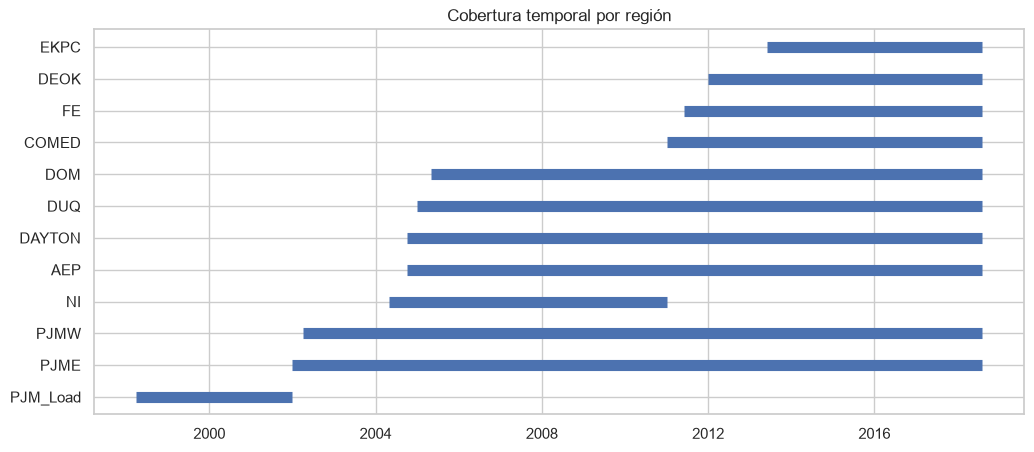

In [98]:
orden = resumen.sort_values('fecha_inicial')

fig, ax = plt.subplots(figsize=(12, 5))
for i, (nombre, r) in enumerate(orden.iterrows()):
    ax.hlines(i, r['fecha_inicial'], r['fecha_final'], linewidth=8)
ax.set_yticks(range(len(orden)))
ax.set_yticklabels(orden.index)
ax.set_title('Cobertura temporal por región')
plt.show()

**Periodo común.** Si no todas las regiones se solapan, la comparación debe hacerse por grupos. La celda calcula el periodo común de las 12 y el de las regiones que llegan hasta el final del dataset (*vigentes*).

In [99]:
inicio_comun = resumen['fecha_inicial'].max()
fin_comun = resumen['fecha_final'].min()
print(f"Periodo común a las {len(resumen)} regiones: {inicio_comun} → {fin_comun}")
print("¿Existe solape entre todas?", inicio_comun < fin_comun)

# Regiones que llegan hasta el final del dataset
corte = resumen['fecha_final'].max() - pd.Timedelta(days=7)
vigentes = resumen[resumen['fecha_final'] >= corte]
print(f"\nRegiones vigentes ({len(vigentes)}): {list(vigentes.index)}")
print(f"Periodo común de las vigentes: {vigentes['fecha_inicial'].max()} → {vigentes['fecha_final'].min()}")
print("Fuera de ese grupo:", [r for r in resumen.index if r not in vigentes.index])

Periodo común a las 12 regiones: 2013-06-01 01:00:00 → 2002-01-01 00:00:00
¿Existe solape entre todas? False

Regiones vigentes (10): ['AEP', 'COMED', 'DAYTON', 'DEOK', 'DOM', 'DUQ', 'EKPC', 'FE', 'PJME', 'PJMW']
Periodo común de las vigentes: 2013-06-01 01:00:00 → 2018-08-03 00:00:00
Fuera de ese grupo: ['NI', 'PJM_Load']


### 3.2 Duplicados

Se revisan todas las regiones. Para cada fecha repetida se mira cuántas filas hay y cuántos valores distintos de MW: si `nunique` es 1 son filas idénticas; si es mayor, hay lecturas diferentes para la misma hora y hay que decidir cómo unificarlas.

In [100]:
detalle_dups = []
for nombre, d in regiones.items():
    dups = d[d.duplicated('Datetime', keep=False)]
    if dups.empty:
        continue
    g = dups.groupby('Datetime')['MW'].agg(['count', 'nunique', 'min', 'max'])
    g.insert(0, 'region', nombre)
    detalle_dups.append(g.reset_index())

detalle_dups = pd.concat(detalle_dups, ignore_index=True)

print("Regiones con duplicados:", detalle_dups['region'].nunique(), "de", len(regiones))
print("Horas del día en que ocurren:", sorted(int(h) for h in detalle_dups['Datetime'].dt.hour.unique()))

# Una fila por fecha duplicada: en cuántas regiones aparece y si los valores difieren
detalle_dups.groupby('Datetime').agg(
    regiones=('region', 'count'),
    max_valores_distintos=('nunique', 'max'),
)

Regiones con duplicados: 10 de 12
Horas del día en que ocurren: [2]


,regiones,max_valores_distintos
Datetime,,
2014-11-02 02:00:00,10,2
2015-11-01 02:00:00,10,2
2016-11-06 02:00:00,10,2
2017-11-05 02:00:00,10,2


In [101]:
# Ejemplo de detalle para una región
detalle_dups[detalle_dups['region'] == 'AEP']

,Datetime,region,count,nunique,min,max
0,2014-11-02 02:00:00,AEP,2,2,12994.0,13190.0
1,2015-11-01 02:00:00,AEP,2,2,10542.0,10785.0
2,2016-11-06 02:00:00,AEP,2,2,10964.0,11008.0
3,2017-11-05 02:00:00,AEP,2,2,10446.0,10596.0


### 3.3 Horas faltantes

Se cuentan por año y región. Un hueco de una o dos horas al año es típico del cambio de horario; cientos de horas en un año indicarían un apagón de datos.

In [102]:
faltantes_anio = pd.DataFrame({
    n: pd.Series(f.year).value_counts() for n, f in faltantes_por_region.items()
}).fillna(0).astype(int).sort_index()

faltantes_anio

,AEP,COMED,DAYTON,DEOK,DOM,DUQ,EKPC,FE,NI,PJM_Load,PJME,PJMW
1998,0,0,0,0,0,0,0,0,0,2,0,0
1999,0,0,0,0,0,0,0,0,0,2,0,0
2000,0,0,0,0,0,0,0,0,0,2,0,0
2001,0,0,0,0,0,0,0,0,0,2,0,0
2002,0,0,0,0,0,0,0,0,0,0,2,2
2003,0,0,0,0,0,0,0,0,0,0,2,2
2004,1,0,1,0,0,0,0,0,1,0,2,2
2005,2,0,2,0,1,2,0,0,2,0,2,2
2006,2,0,2,0,2,2,0,0,2,0,2,2
2007,2,0,2,0,2,2,0,0,2,0,2,2


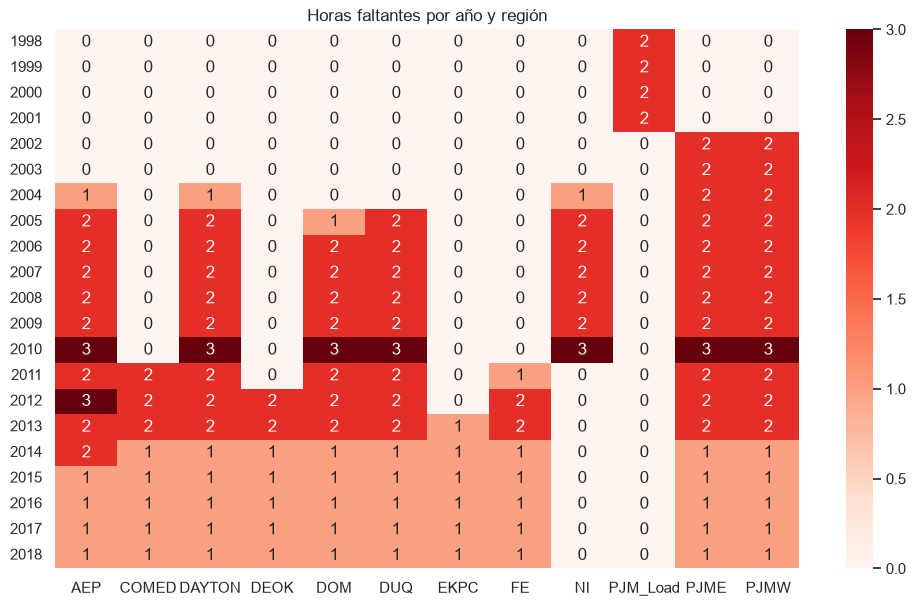

In [103]:
fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(faltantes_anio, annot=True, fmt='d', cmap='Reds', ax=ax)
ax.set_title('Horas faltantes por año y región')
plt.show()

In [104]:
# ¿En qué fechas y meses caen? (ejemplo con PJME)
f = faltantes_por_region['PJME']
print("Meses en que faltan horas:", pd.Series(f.month).value_counts().sort_index().to_dict())
list(f.strftime('%Y-%m-%d %H:%M'))

Meses en que faltan horas: {3: 12, 4: 5, 10: 5, 11: 7, 12: 1}


['2002-04-07 03:00',
 '2002-10-27 02:00',
 '2003-04-06 03:00',
 '2003-10-26 02:00',
 '2004-04-04 03:00',
 '2004-10-31 02:00',
 '2005-04-03 03:00',
 '2005-10-30 02:00',
 '2006-04-02 03:00',
 '2006-10-29 02:00',
 '2007-03-11 03:00',
 '2007-11-04 02:00',
 '2008-03-09 03:00',
 '2008-11-02 02:00',
 '2009-03-08 03:00',
 '2009-11-01 02:00',
 '2010-03-14 03:00',
 '2010-11-07 02:00',
 '2010-12-10 00:00',
 '2011-03-13 03:00',
 '2011-11-06 02:00',
 '2012-03-11 03:00',
 '2012-11-04 02:00',
 '2013-03-10 03:00',
 '2013-11-03 02:00',
 '2014-03-09 03:00',
 '2015-03-08 03:00',
 '2016-03-13 03:00',
 '2017-03-12 03:00',
 '2018-03-11 03:00']

### 3.4 Valores atípicos y sospechosos

Los valores altos en consumo eléctrico suelen ser picos reales de demanda, no errores. Por eso el conteo por rango intercuartil se separa en bajos y altos, y se revisan aparte los valores más bajos de cada región (un cero o un valor muy por debajo del promedio puede ser un error de medición).

In [105]:
df.groupby('region')['MW'].describe().round(0)

,count,mean,std,min,25%,50%,75%,max
region,,,,,,,,
AEP,121273.0,15500.0,2591.0,9581.0,13630.0,15310.0,17200.0,25695.0
COMED,66497.0,11420.0,2304.0,7237.0,9780.0,11152.0,12510.0,23753.0
DAYTON,121275.0,2038.0,393.0,982.0,1749.0,2009.0,2279.0,3746.0
DEOK,57739.0,3105.0,600.0,907.0,2687.0,3013.0,3449.0,5445.0
DOM,116189.0,10949.0,2414.0,1253.0,9322.0,10501.0,12378.0,21651.0
DUQ,119068.0,1659.0,302.0,1014.0,1444.0,1630.0,1819.0,3054.0
EKPC,45334.0,1464.0,379.0,514.0,1185.0,1386.0,1699.0,3490.0
FE,62874.0,7792.0,1331.0,0.0,6807.0,7700.0,8556.0,14032.0
NI,58450.0,11702.0,2371.0,7003.0,9954.0,11521.0,12897.0,23631.0


In [106]:
def contar_atipicos(s):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    return pd.Series({
        'bajos': int((s < q1 - 1.5 * iqr).sum()),
        'altos': int((s > q3 + 1.5 * iqr).sum()),
    })

df.groupby('region')['MW'].apply(contar_atipicos).unstack()

,bajos,altos
region,,
AEP,0,667
COMED,0,2388
DAYTON,0,1535
DEOK,34,1166
DOM,1,2105
DUQ,0,3391
EKPC,0,732
FE,1,1183
NI,0,1816


In [107]:
# Los 3 valores más bajos de cada región
(df.sort_values('MW')
   .groupby('region')
   .head(3)
   .sort_values(['region', 'MW']))

,Datetime,MW,region
105197,2016-10-02 05:00:00,9581.0,AEP
105198,2016-10-02 06:00:00,9604.0,AEP
105196,2016-10-02 04:00:00,9623.0,AEP
151032,2014-05-25 07:00:00,7237.0,COMED
179927,2017-09-10 06:00:00,7263.0,COMED
151033,2014-05-25 08:00:00,7269.0,COMED
222435,2008-09-14 18:00:00,982.0,DAYTON
249340,2011-10-11 02:00:00,1000.0,DAYTON
222445,2008-09-15 04:00:00,1011.0,DAYTON
364316,2018-04-22 05:00:00,907.0,DEOK


## 4. Distribución y series de tiempo

Las regiones tienen tamaños muy distintos (por ejemplo, PJME consume unas veinte veces más que DUQ), así que la escala del eje cambia de una región a otra.

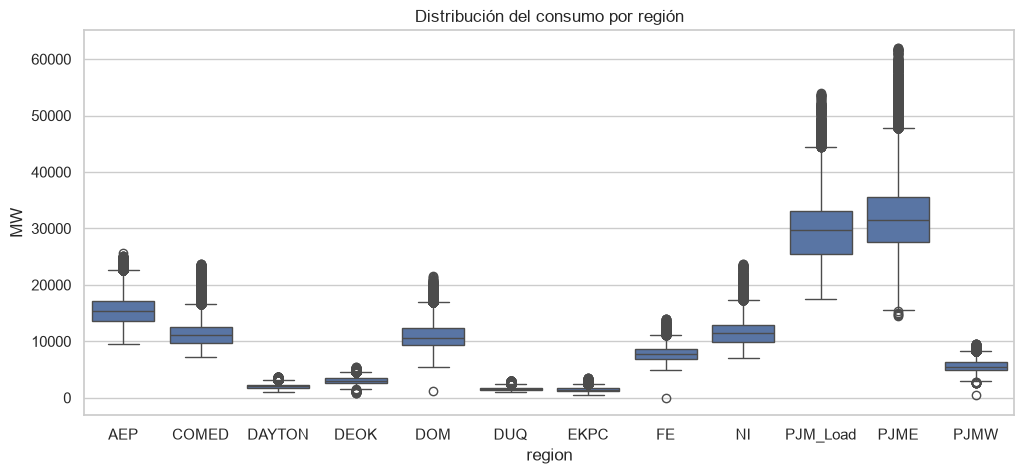

In [108]:
fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(data=df, x='region', y='MW', ax=ax)
ax.set_title('Distribución del consumo por región')
plt.show()

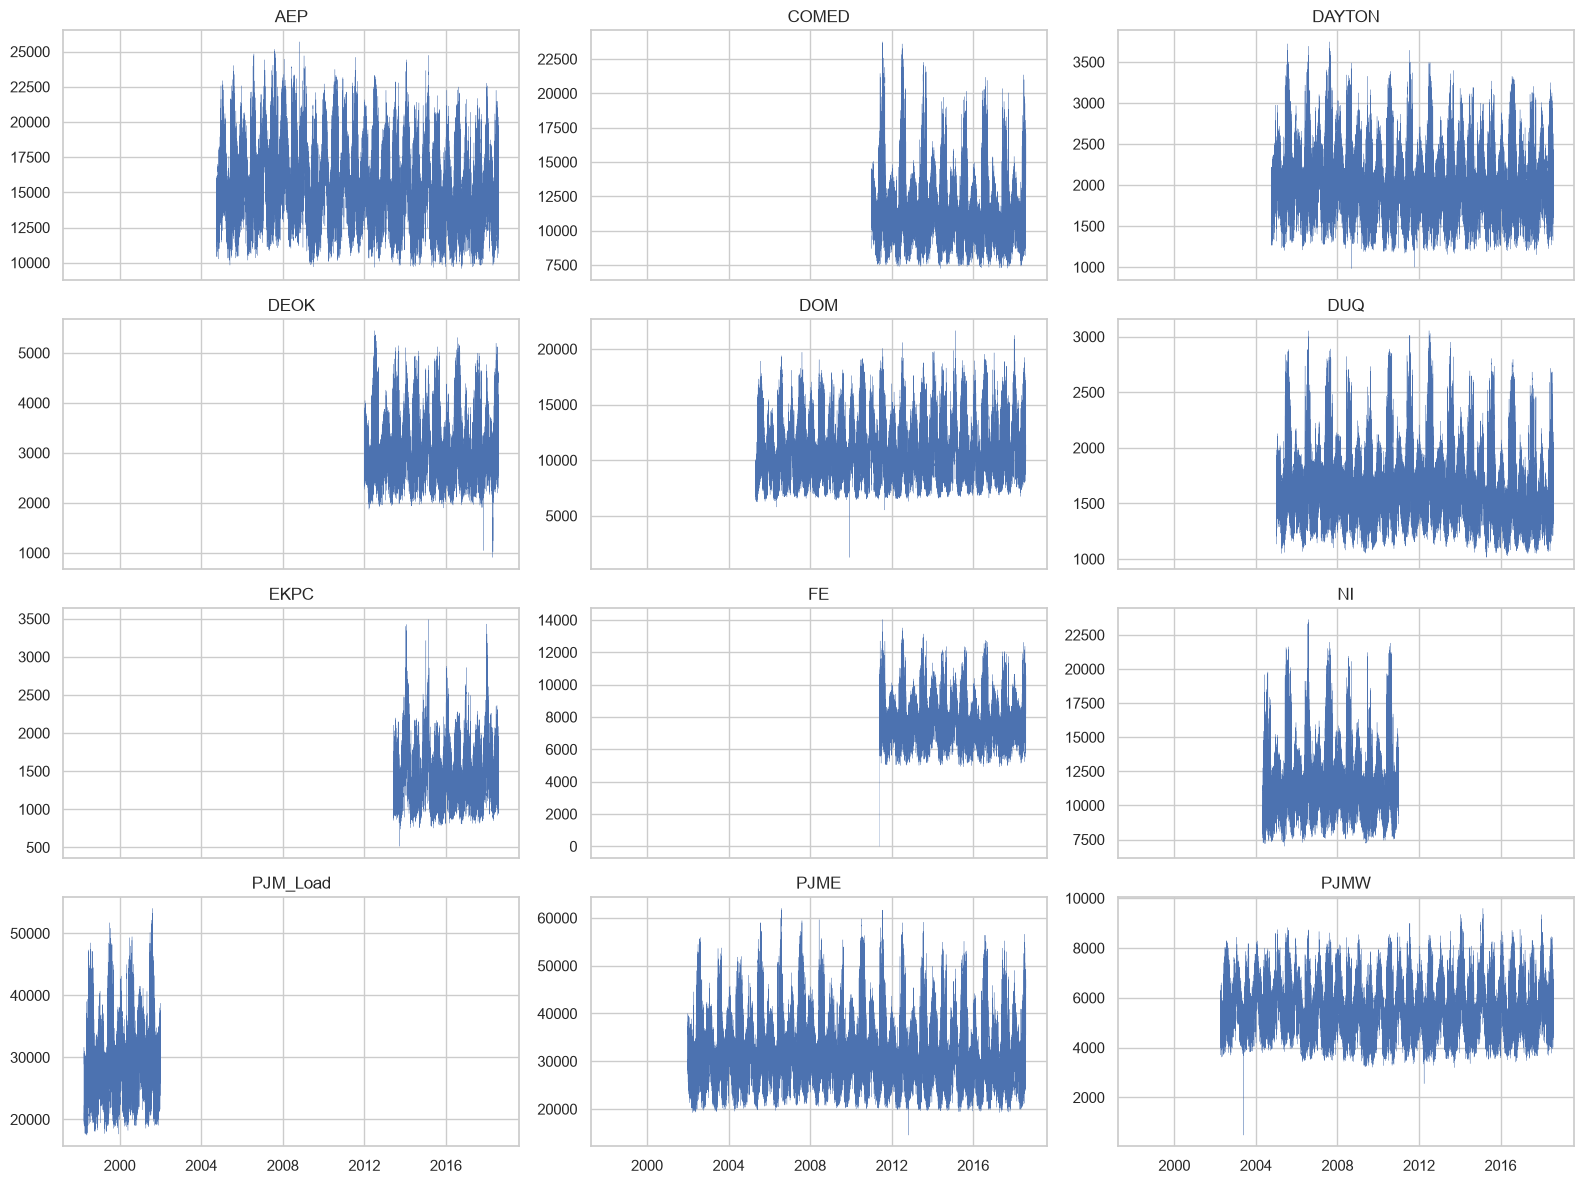

In [109]:
fig, axes = plt.subplots(4, 3, figsize=(16, 12), sharex=True)
for ax, (nombre, d) in zip(axes.flat, regiones.items()):
    ax.plot(d['Datetime'], d['MW'], linewidth=0.2)
    ax.set_title(nombre)
plt.tight_layout()
plt.show()

## 5. Primeros patrones temporales

Para que la comparación sea justa se usan solo las regiones vigentes y su periodo común (sección 3.1). Además, cada perfil se divide entre el promedio de su región: así se compara la **forma** del consumo y no su magnitud (1.2 significa 20 % por encima de lo habitual para esa región).

In [110]:
inicio_v = vigentes['fecha_inicial'].max()
fin_v = vigentes['fecha_final'].min()

df_comun = (
    df[df['region'].isin(vigentes.index) & df['Datetime'].between(inicio_v, fin_v)]
    .assign(
        hora=lambda x: x['Datetime'].dt.hour,
        dia_semana=lambda x: x['Datetime'].dt.dayofweek,   # 0 = lunes
        mes=lambda x: x['Datetime'].dt.month,
    )
)
print(f"{df_comun['region'].nunique()} regiones · {inicio_v:%Y-%m-%d} → {fin_v:%Y-%m-%d}")

10 regiones · 2013-06-01 → 2018-08-03


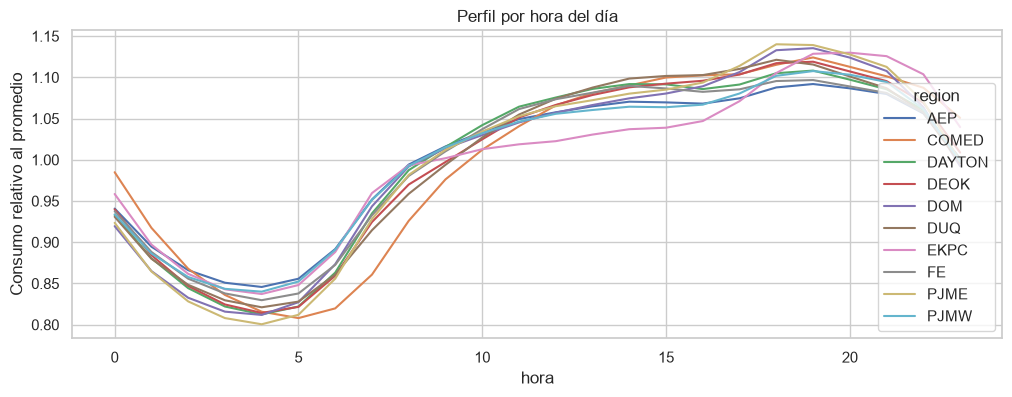

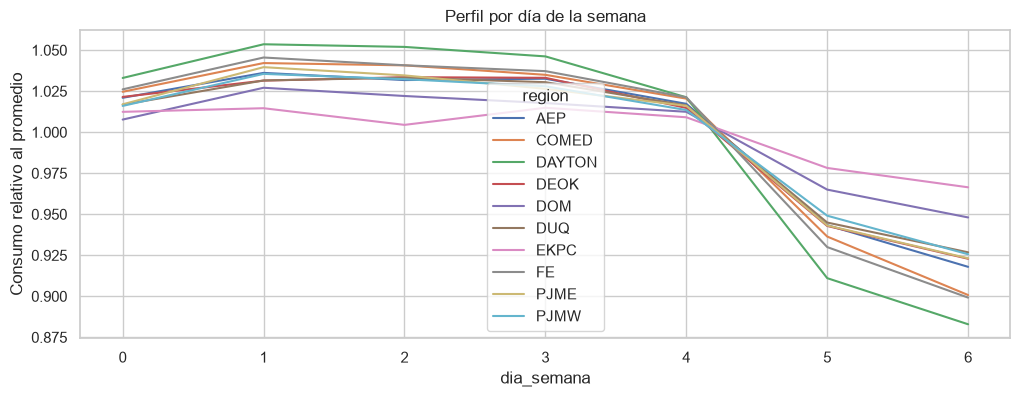

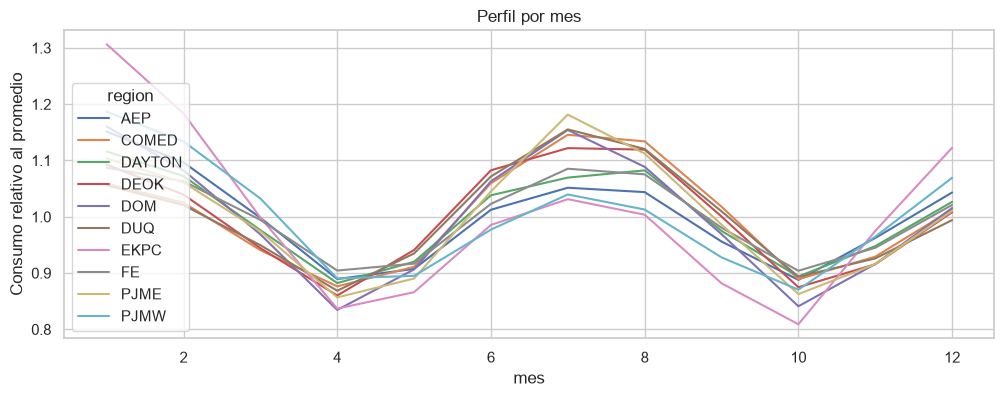

In [111]:
for col, titulo in [('hora', 'Perfil por hora del día'),
                    ('dia_semana', 'Perfil por día de la semana'),
                    ('mes', 'Perfil por mes')]:
    perfil = df_comun.groupby(['region', col])['MW'].mean().unstack(0)
    (perfil / perfil.mean()).plot(figsize=(12, 4), title=titulo)
    plt.ylabel('Consumo relativo al promedio')
    plt.show()

## 6. Hallazgos

| Tema | Hallazgo |
|---|---|
| Estructura | 12 regiones y 1,090,167 filas. `Datetime` es `datetime64` y `MW` es `float64`. Sin nulos en ninguna región. |
| Periodo común | **No existe un periodo común a las 12 regiones.** `PJM_Load` cubre 1998-04 → 2002-01 y `NI` 2004-05 → 2011-01; las otras 10 llegan hasta 2018-08-03. Las 10 vigentes comparten 2013-06-01 → 2018-08-03. |
| Cobertura | Entre 99.98 % y 99.99 % en todas las regiones. |
| Duplicados | 4 fechas repetidas en 10 regiones (no en `NI` ni `PJM_Load`), todas en noviembre. En AEP son las 02:00 de 2014-11-02, 2015-11-01, 2016-11-06 y 2017-11-05, con valores distintos para la misma hora: coincide con el cambio de horario de otoño. |
| Horas faltantes | Entre 6 y 30 horas por región, de 1 a 3 por año. Hasta 2013 faltan 2 por año y desde 2014 solo 1, justo cuando aparecen los duplicados de otoño. Sugiere hora local con cambio de horario; confirmar con las fechas de la sección 3.3. |
| Valores sospechosos | `FE` tiene un valor en 0 MW. Otros mínimos parecen muy bajos frente a su promedio (`PJMW` 487, `DOM` 1,253, `EKPC` 514): revisar en la sección 3.4. |
| Atípicos (IQR) | Entre 567 y 3,455 por región; falta separar cuántos son bajos y cuántos altos. |
| Escala | Las magnitudes difieren mucho (`PJME` ≈ 32,080 MW de media frente a `DUQ` ≈ 1,659 MW). Para comparar formas hay que normalizar. |